# T-maze

**Objective:** Compare hyperparameters and evaluate spatial features pyramidal neurons learn to encode.

* T-maze
* Agent navigation is largely fixed based on a randomly selected target arm for each trajectory.
* Target object initially located near end of one arm.
* Two-compartment pyramidal neuron layer:
  * Somatic input: jittered, but uniformly distributed Gaussian place cells (plastic)
  * Dendritic input: Target object-encoding cell (fixed)
  * Filtered dendritic self-inhibition
  * 1 pyramidal neuron only
* Learning:
  * BTSP learning: strong learning with a broad kernel, occurring when a neuron's activation passes a predetermined threshold.

In [1]:
import copy
from typing import Any
import warnings

from matplotlib import pyplot as plt
import numpy as np
import ratinabox
from tqdm import tqdm

from predhpc import agent, env, run_manager, plot_fcts
from predhpc.neurons import learning_neurons, two_comp_neurons, object_neurons
from predhpc.util import learn_util, plot_util, params_util

In [2]:
plot_util.stylize_plots_for_notebook()
ratinabox.autosave_plots = False
ratinabox.figure_directory = "figures"

In [3]:
warnings.filterwarnings(
    "ignore", message="invalid value encountered", 
    category=RuntimeWarning
)

In [4]:
import importlib
importlib.reload(agent)
importlib.reload(env)
importlib.reload(learning_neurons)
importlib.reload(two_comp_neurons)
importlib.reload(object_neurons)
importlib.reload(run_manager)
importlib.reload(learn_util)
importlib.reload(plot_util)
importlib.reload(params_util);

## 1. Initial target location

In [5]:
env_params = params_util.get_env_params(environment="tmaze")

agent_params = params_util.get_agent_params(
    environment="tmaze", left_arm_prop=0.8
)

PC_params = params_util.get_PC_params(
    environment="tmaze", place_cell_centres="uniform"
)

Pyr_params = params_util.get_Pyr_params(
    n=1, environment="tmaze", 
    two_compartment=True, BTSP=True,
)

100%|██████████████████████████████████████| 8000/8000 [00:16<00:00, 492.36it/s]


Only reached the reward 2 times (target: 8).
Trajectory lengths (9) to date: 26.67 +/- 3.59 sec each
Trajectory lengths (9) to date: 888.89 +/- 119.76 steps each


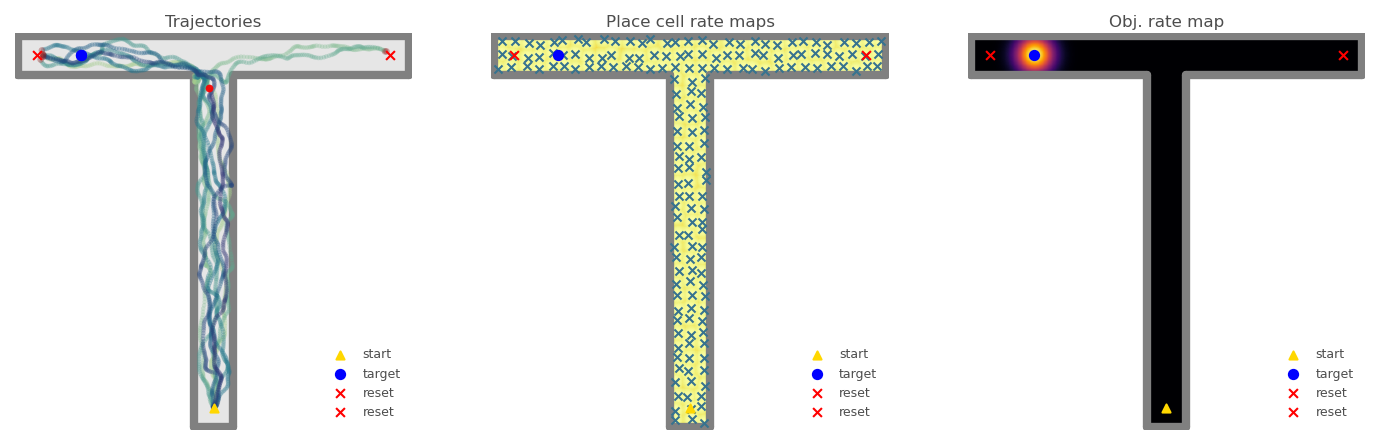

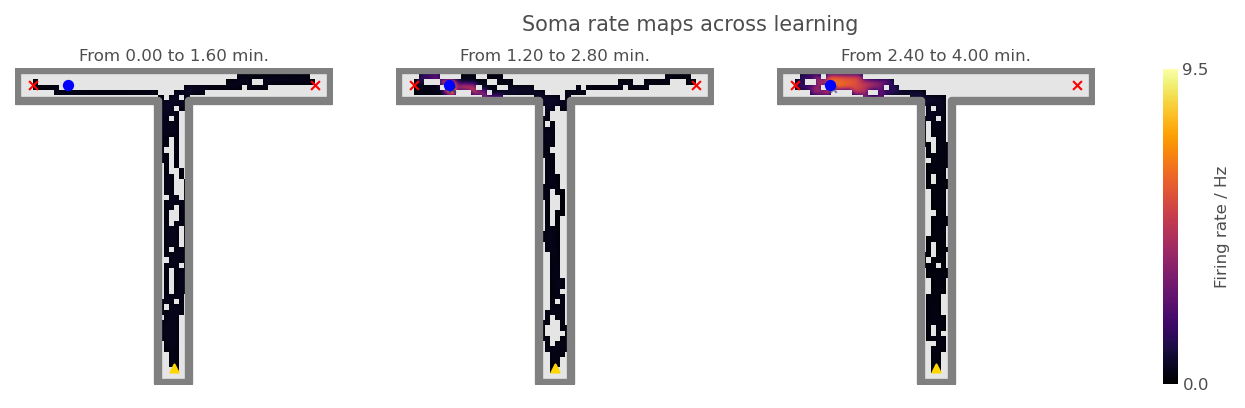

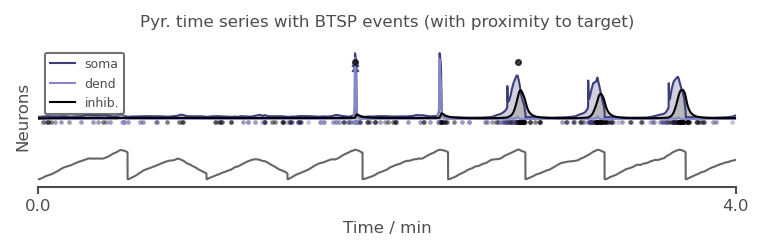

In [6]:
PC_params = params_util.get_PC_params(
    environment="tmaze", 
    n= 177, # 40, # for one column and one row 
    place_cell_centres="uniform_jitter"
)

Pyrs = run_manager.learn_T_maze_BTSP(
    env_params=env_params, 
    agent_params=agent_params, 
    PC_params=PC_params, 
    Pyr_params=Pyr_params, 
    num_rewards=8, 
    max_num_steps=8000, 
    weight_recording_freq=100, 
    use_Hebbian=False,
    BTSP_after_num_target_reaches=1,
    two_compartment=True
)

_, Ag, PCs, Pyrs, Objs = run_manager.extract_objects_from_Pyrs(Pyrs)

### Place cell rate maps

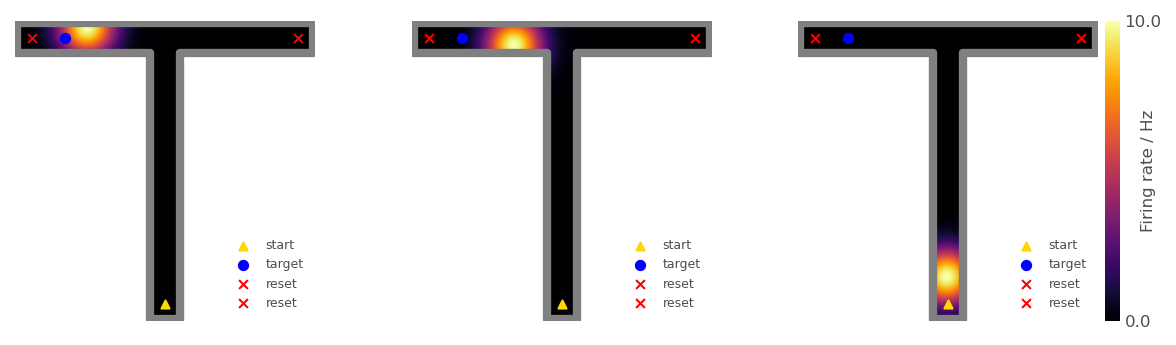

In [7]:
num_plots = 3
chosen_neurons = np.random.choice(PCs.n, 3, replace=False)
_, ax1D = plt.subplots(1, num_plots, figsize=(num_plots * 2.5, 2))
PCs.plot_rate_map(chosen_neurons=chosen_neurons, ax=ax1D);

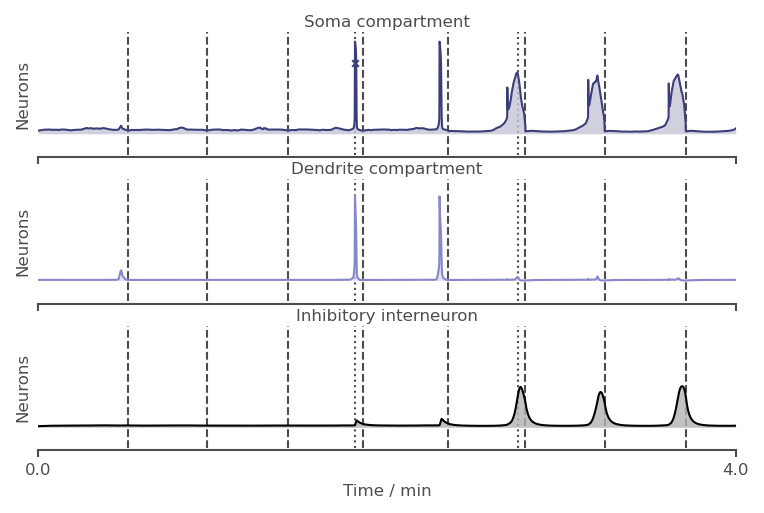

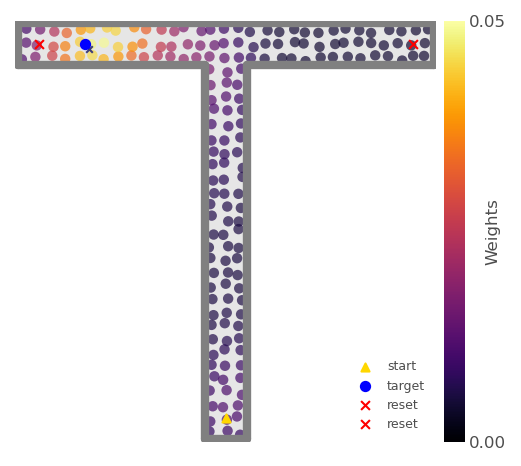

In [8]:
Pyrs.plot_rate_timeseries(separate_axes=True, norm_by="shared_max")

fig, ax = plt.subplots(figsize=[3, 3])
plot_fcts.plot_2D_input_place_cell_weights(Pyrs.SomaCompartment, ax=ax, s=25, plot_BTSP_events=True);

### Assessments based on theoretical kernel

/home/cgillon/Documents/predhpc/predhpc/util/learn_util.py:830: UserWarning: Assessment will assume geodesic wall geometry even though place cell wall geometry is line_of_sight.
  warnings.warn(
/home/cgillon/Documents/predhpc/predhpc/util/learn_util.py:835: UserWarning: Actual place cell centres were initialized as uniform_jitter, but assessment will assume uniformly arranged place cell centres.
  warnings.warn(


Update 1 regul.: 4.0136 (w)


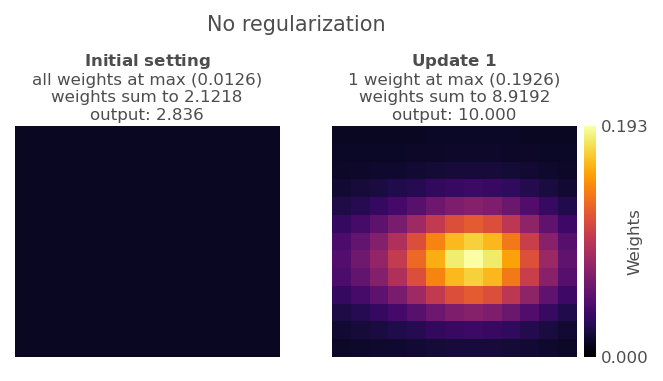

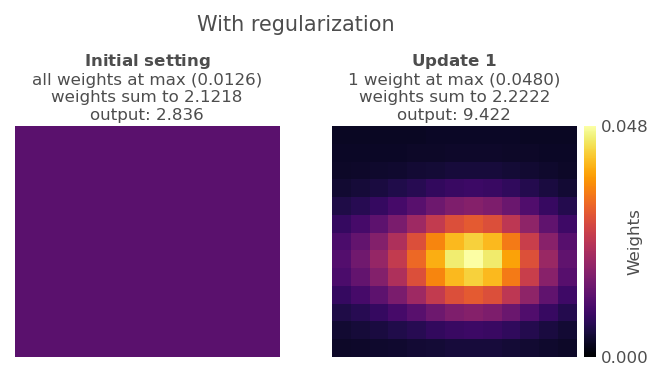

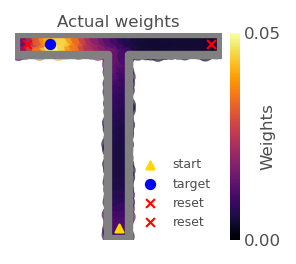

In [9]:
importlib.reload(learn_util)
importlib.reload(plot_util)

OUTPUT_FR = 6 # tuned to match actual weights as closely as possible

for normalize_weights_divisively in [False, True]:
    assessment_dict = learn_util.assess_Pyrs_lr_factors(
        Pyrs.SomaCompartment, 
        normalize_weights_divisively=normalize_weights_divisively, 
        output_fr=OUTPUT_FR, 
        log_reg=True,
    )
    axes = plot_util.plot_lr_factor_assessment(assessment_dict)
    title_str = "With" if normalize_weights_divisively else "No"
    axes.ravel()[0].figure.suptitle(f"{title_str} regularization", y=1.25)

axes = plot_fcts.plot_2D_input_place_cell_weights(Pyrs.SomaCompartment)
axes.ravel()[0].set_title("Actual weights");

BTSP events applied after 1074.00 steps (32.22 sec.) (num steps: 1074).


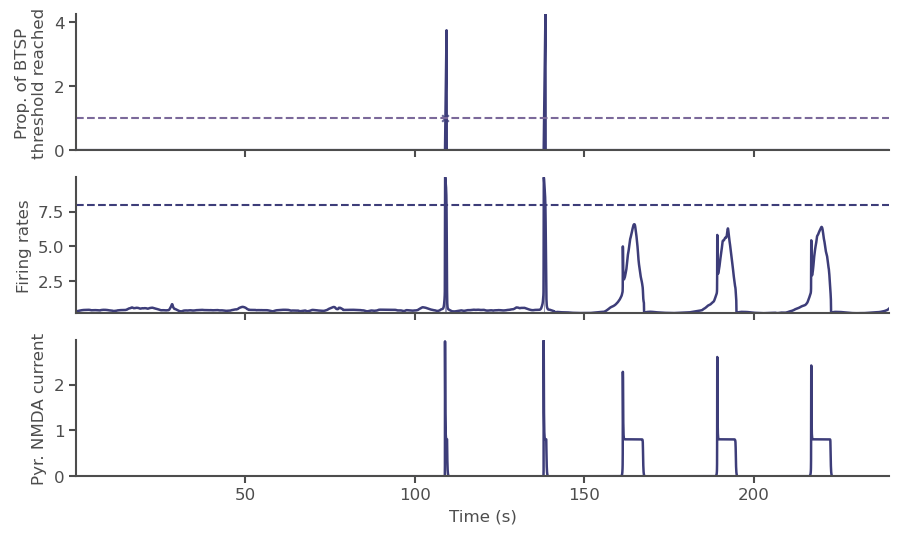

In [10]:
Pyrs.SomaCompartment.log_num_steps_to_apply_BTSP()
Pyrs.SomaCompartment.plot_BTSP_ramp();

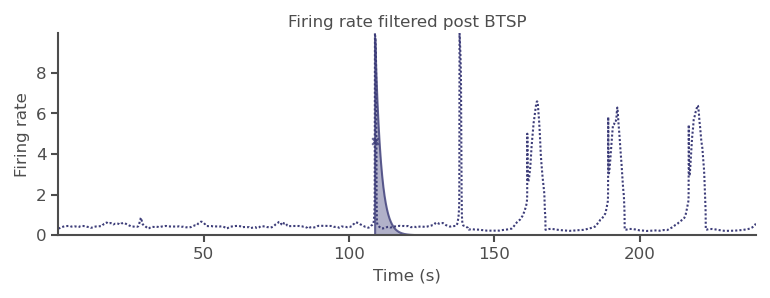

In [11]:
Pyrs.SomaCompartment.plot_filtered_for_BTSP();

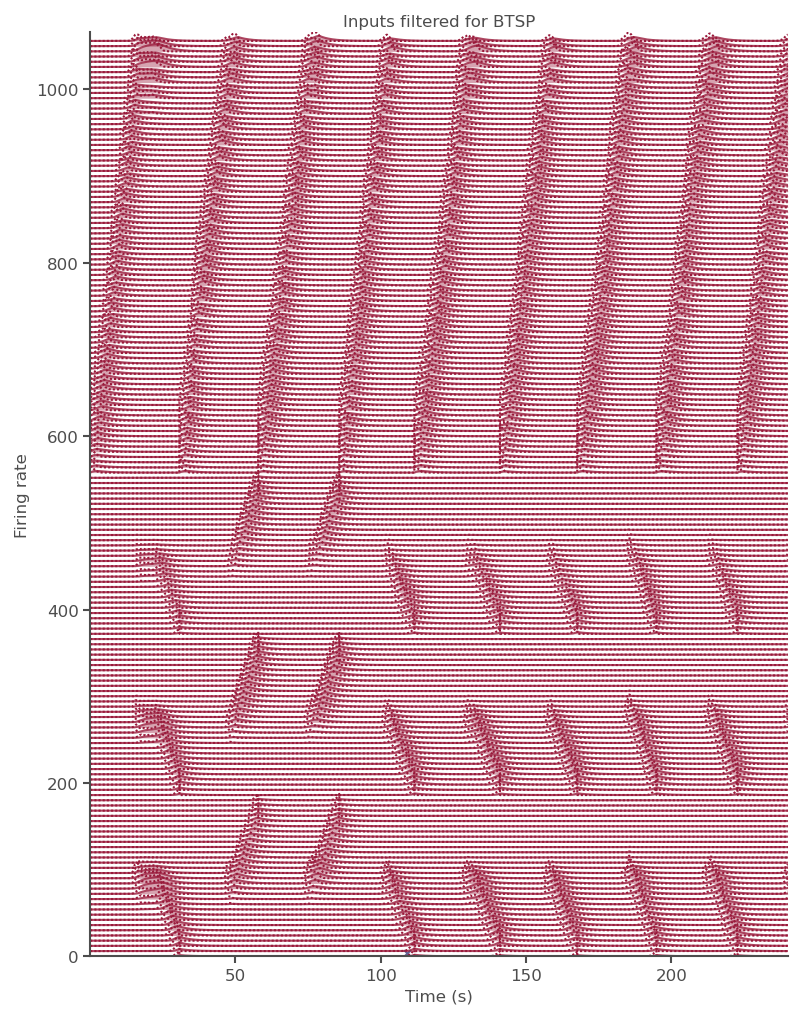

In [12]:
Pyrs.SomaCompartment.plot_filtered_for_BTSP("PCs");

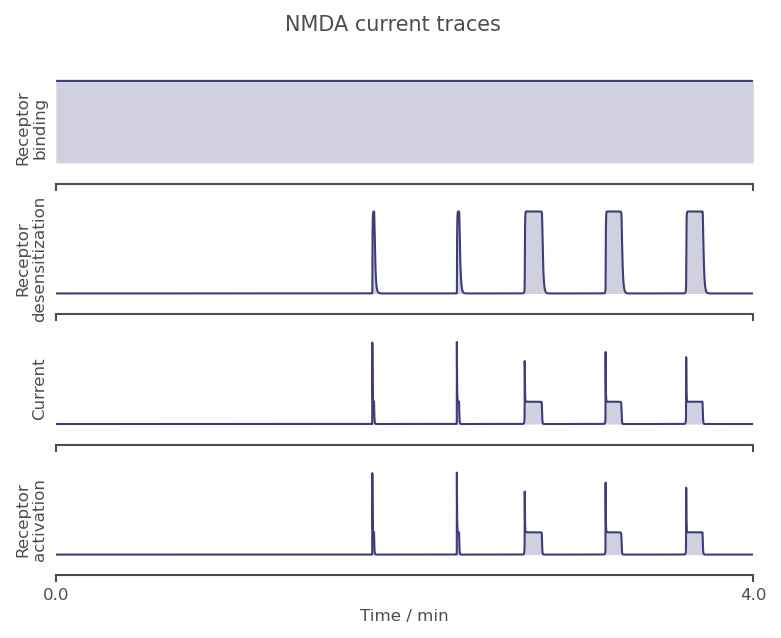

In [13]:
Pyrs.SomaCompartment.inputs["NMDACurrent"]["layer"].plot_timeseries(datatypes="all");

In [14]:
Ag.target_df

,target_arm,position_x,position_y,set_step,set_time,reached_step,reached_time,num_steps_total,time_total
0,left,0.4875,2.85,0,0.00,3631.0,108.93,3631.0,108.93
1,left,0.4875,2.85,3631,108.93,5499.0,164.97,1868.0,56.04
2,left,0.4875,2.85,5499,164.97,NaN,NaN,NaN,NaN


In [15]:
Ag.trajectory_df

,start_position_x,start_position_y,start_step,start_time,stop_position_x,stop_position_y,stop_step,stop_time,num_steps_total,time_total
0,1.498834,0.150061,0,0.00,0.192462,2.838067,1023.0,30.69,1023.0,30.69
1,1.500593,0.149126,1023,30.69,2.816051,2.838067,1928.0,57.84,905.0,27.15
2,1.498885,0.150401,1928,57.84,2.824641,2.838067,2857.0,85.71,929.0,27.87
3,1.499056,0.150377,2857,85.71,0.176135,2.838067,3718.0,111.54,861.0,25.83
4,1.498892,0.150061,3718,111.54,0.193126,2.838067,4699.0,140.97,981.0,29.43
5,1.500893,0.150156,4699,140.97,0.176623,2.838067,5586.0,167.58,887.0,26.61
6,1.499069,0.149548,5586,167.58,0.191257,2.838067,6494.0,194.82,908.0,27.24
7,1.501010,0.149424,6494,194.82,0.187352,2.838067,7424.0,222.72,930.0,27.90
8,1.498895,0.150089,7424,222.72,NaN,NaN,NaN,NaN,NaN,NaN


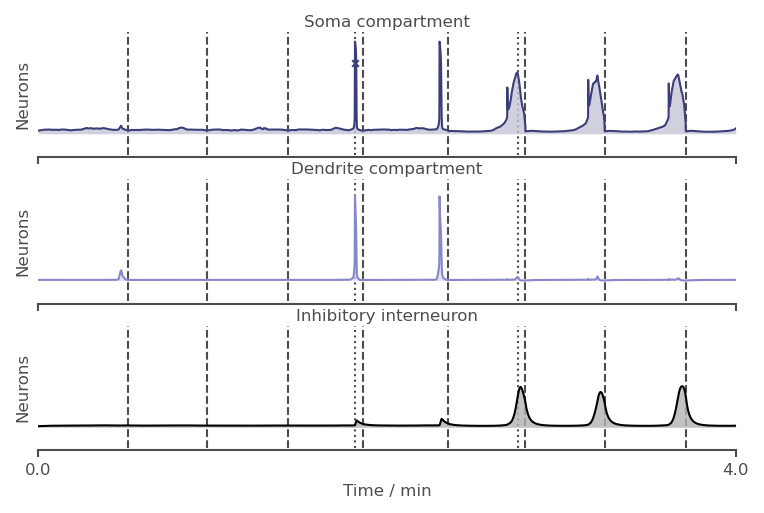

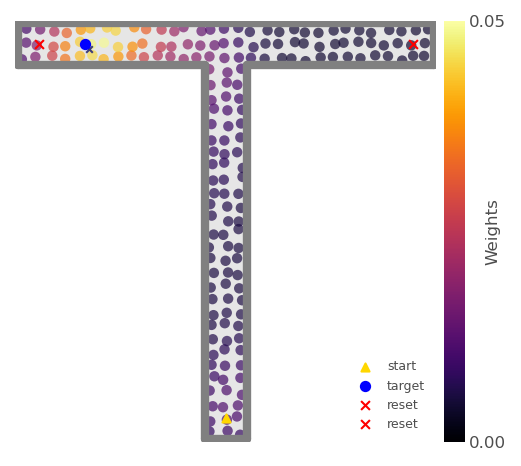

In [16]:
ax_time = Pyrs.plot_rate_timeseries(separate_axes=True, norm_by="shared_max")

fig_weights, ax_weights = plt.subplots(figsize=[3, 3])
plot_fcts.plot_2D_input_place_cell_weights(Pyrs.SomaCompartment, ax=ax_weights, s=25, plot_BTSP_events=True);

## 2. Move target

In [17]:
_, Ag, PCs, Pyrs, Objs = run_manager.extract_objects_from_Pyrs(Pyrs)

Pyrs.Agent.set_target_position([1.5, 1.7])

In [18]:
num_steps = 2500
for i in tqdm(range(2500)):
    Ag.update(speed_fact=3, drift_to_random_strength_ratio=1)
    Objs.update()
    PCs.update()
    Pyrs.update()

100%|██████████████████████████████████████| 2500/2500 [00:05<00:00, 482.59it/s]


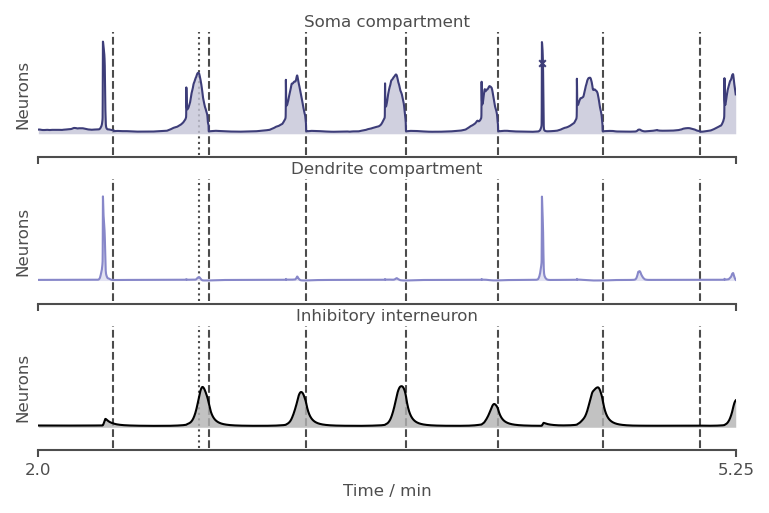

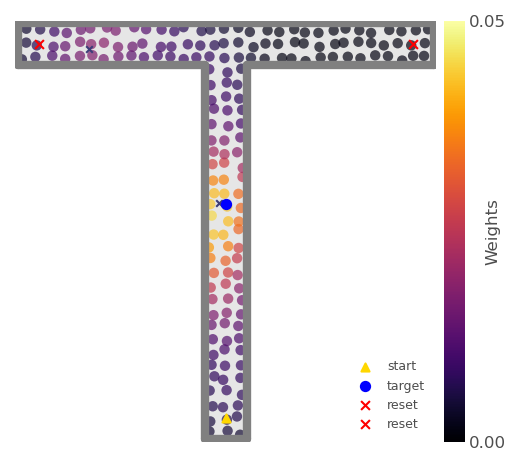

In [19]:
ax_time = Pyrs.plot_rate_timeseries(t_start=2*60, separate_axes=True, norm_by="shared_max")

fig_weights, ax_weights = plt.subplots(figsize=[3, 3])
plot_fcts.plot_2D_input_place_cell_weights(Pyrs.SomaCompartment, ax=ax_weights, s=25, plot_BTSP_events=True);

## 3. Test inhibition hyperparameter

### a. Insufficient dendritic self-inhibition
Multiple BTSP events is similar locations

In [20]:
INHIBIT_WEIGHT = 0.8

In [21]:
DT = params_util.DT

env_params = params_util.get_env_params(environment="tmaze")

agent_params = params_util.get_agent_params(
    environment="tmaze", dt=DT, left_arm_prop=0.8
)

PC_params = params_util.get_PC_params(
    environment="tmaze", place_cell_centres="uniform"
)

Pyr_params = params_util.get_Pyr_params(
    n=1, environment="tmaze", 
    two_compartment=True, BTSP=True,
    inhibit_weight=INHIBIT_WEIGHT,
)

100%|██████████████████████████████████████| 6000/6000 [00:11<00:00, 504.70it/s]


Only reached the reward 5 times (target: 12).
Trajectory lengths (7) to date: 25.71 +/- 6.60 sec each
Trajectory lengths (7) to date: 857.14 +/- 219.84 steps each


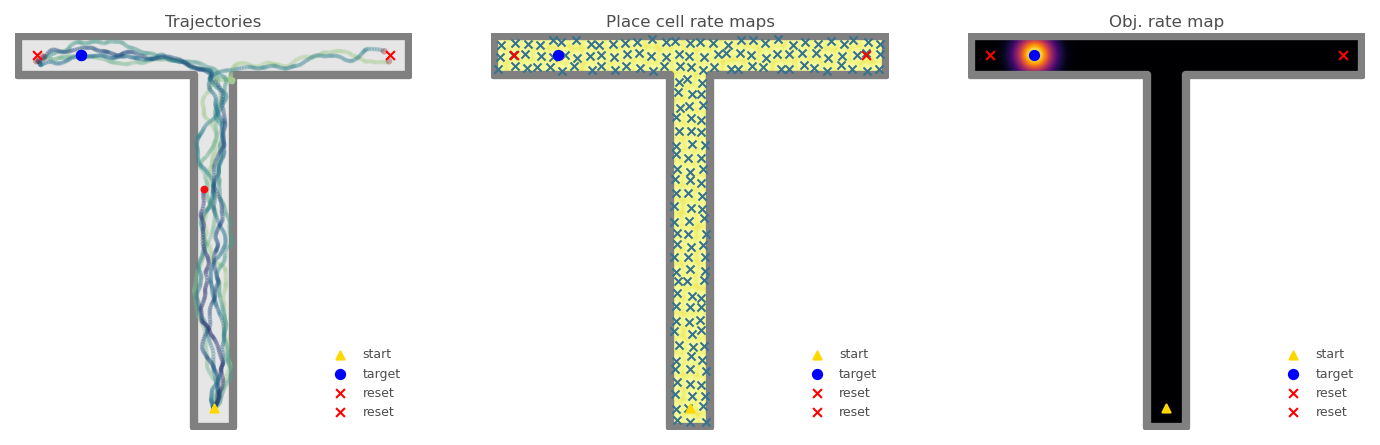

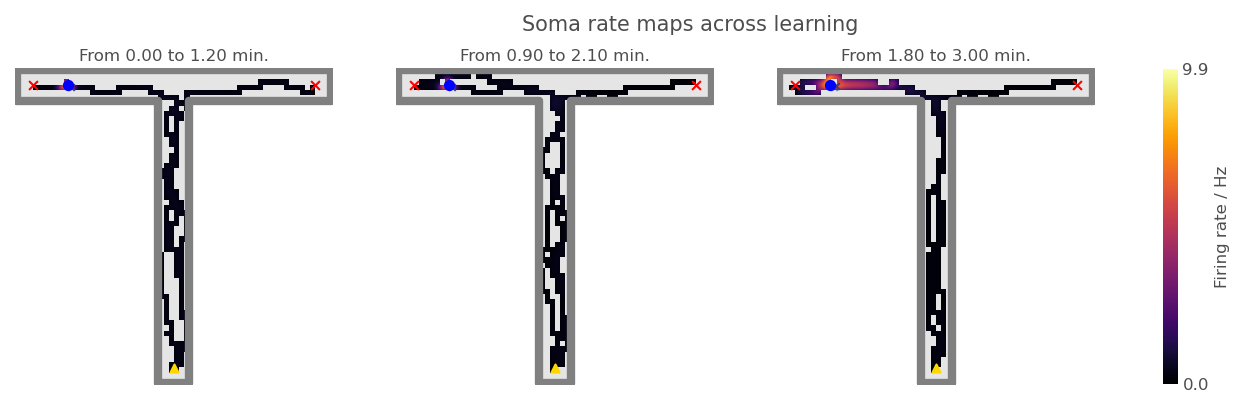

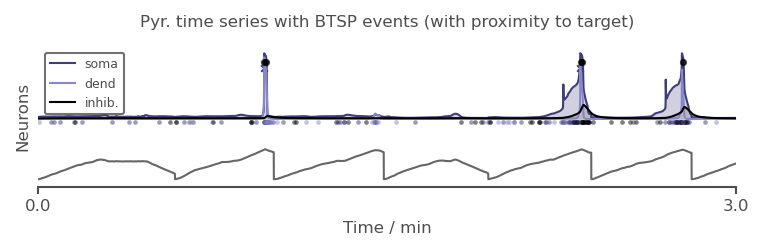

In [22]:
PC_params = params_util.get_PC_params(
    environment="tmaze", 
    n=177,
    place_cell_centres="uniform_jitter"
)

Pyrs = run_manager.learn_T_maze_BTSP(
    env_params=env_params, 
    agent_params=agent_params, 
    PC_params=PC_params, 
    Pyr_params=Pyr_params, 
    num_rewards=12, 
    max_num_steps=6000, 
    weight_recording_freq=100, 
    use_Hebbian=False,
    BTSP_after_num_target_reaches=2, # ignored if 2-compartment
    two_compartment=True
)

_, Ag, PCs, Pyrs, Objs = run_manager.extract_objects_from_Pyrs(Pyrs)

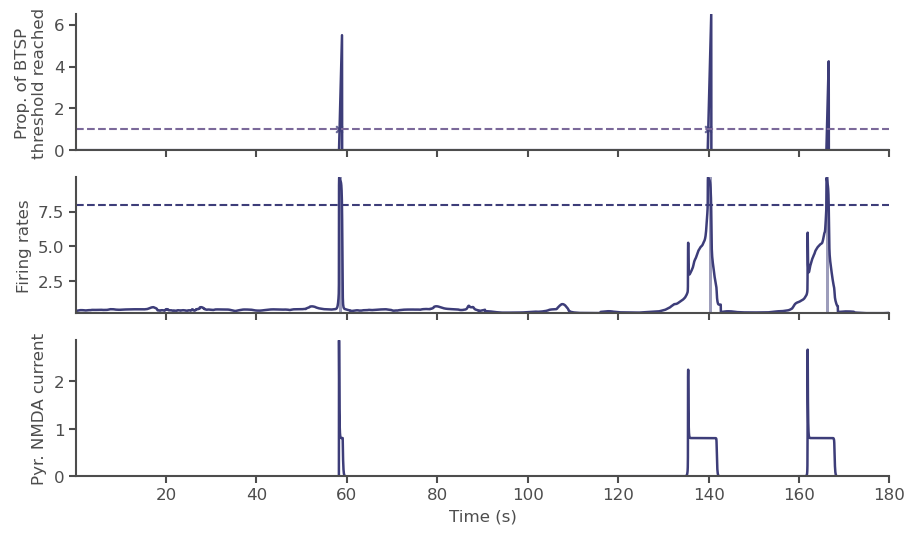

In [23]:
Pyrs.SomaCompartment.plot_BTSP_ramp();

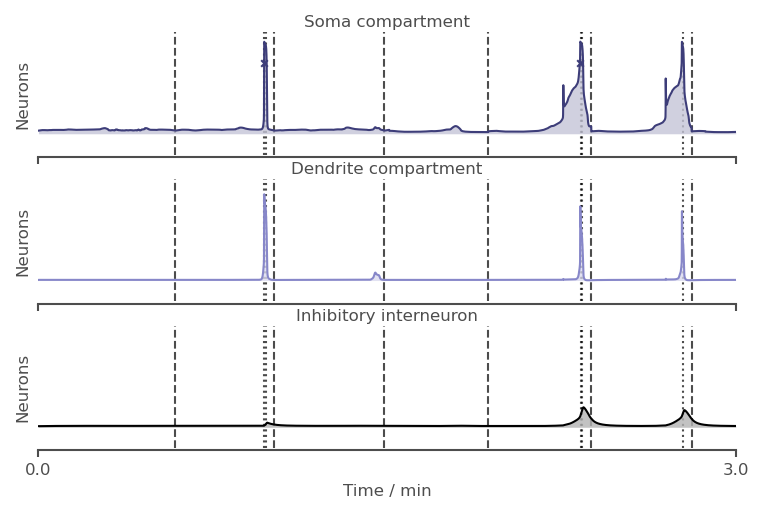

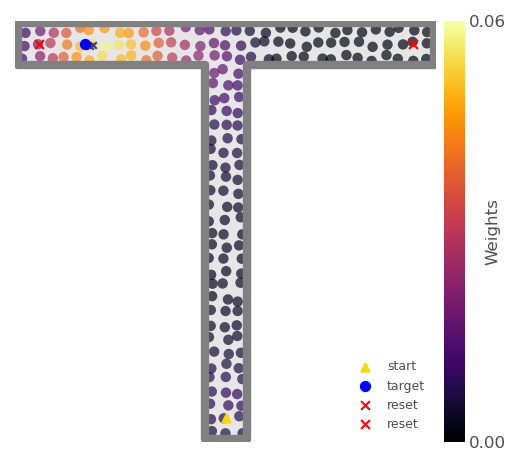

In [24]:
ax_time = Pyrs.plot_rate_timeseries(separate_axes=True, norm_by="shared_max")

fig_weights, ax_weights = plt.subplots(figsize=[3, 3])
plot_fcts.plot_2D_input_place_cell_weights(Pyrs.SomaCompartment, ax=ax_weights, s=25, plot_BTSP_events=True);

### b. Excess dendritic self-inhibiton
BTSP is unlikely to occur.

In [25]:
INHIBIT_WEIGHT = 8.0

In [26]:
DT = params_util.DT

env_params = params_util.get_env_params(environment="tmaze")

agent_params = params_util.get_agent_params(
    environment="tmaze", dt=DT, left_arm_prop=0.8
)

PC_params = params_util.get_PC_params(
    environment="tmaze", place_cell_centres="uniform"
)

Pyr_params = params_util.get_Pyr_params(
    n=1, environment="tmaze", 
    two_compartment=True, BTSP=True,
    inhibit_weight=INHIBIT_WEIGHT,
)

100%|██████████████████████████████████████| 6000/6000 [00:12<00:00, 495.46it/s]


Only reached the reward 4 times (target: 12).
Trajectory lengths (7) to date: 25.71 +/- 3.17 sec each
Trajectory lengths (7) to date: 857.14 +/- 105.70 steps each


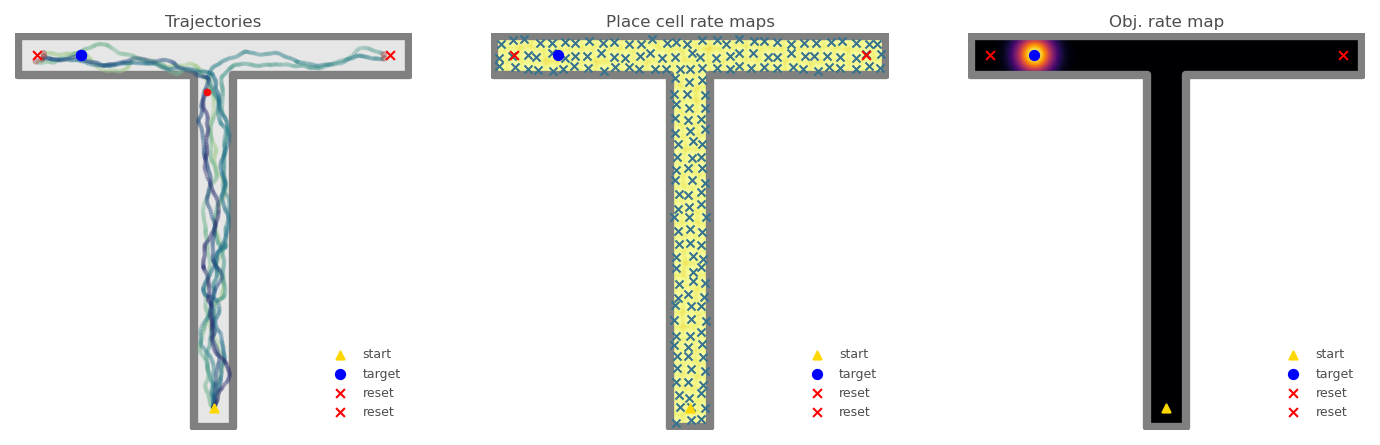

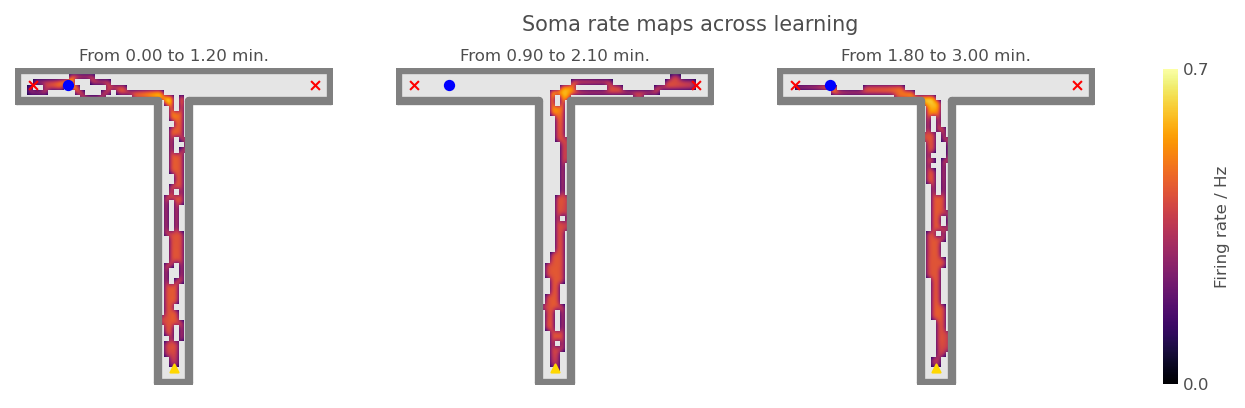

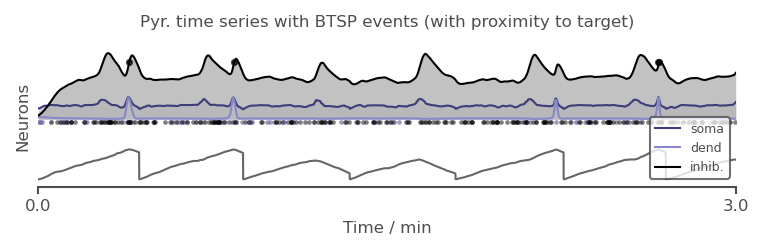

In [27]:
PC_params = params_util.get_PC_params(
    environment="tmaze", 
    n=177, # 40, # for one column and one row 
    place_cell_centres="uniform_jitter"
)

Pyrs = run_manager.learn_T_maze_BTSP(
    env_params=env_params, 
    agent_params=agent_params, 
    PC_params=PC_params, 
    Pyr_params=Pyr_params, 
    num_rewards=12, 
    max_num_steps=6000, 
    weight_recording_freq=100, 
    use_Hebbian=False,
    BTSP_after_num_target_reaches=2, # ignored if 2-compartment
    two_compartment=True
)

_, Ag, PCs, Pyrs, Objs = run_manager.extract_objects_from_Pyrs(Pyrs)

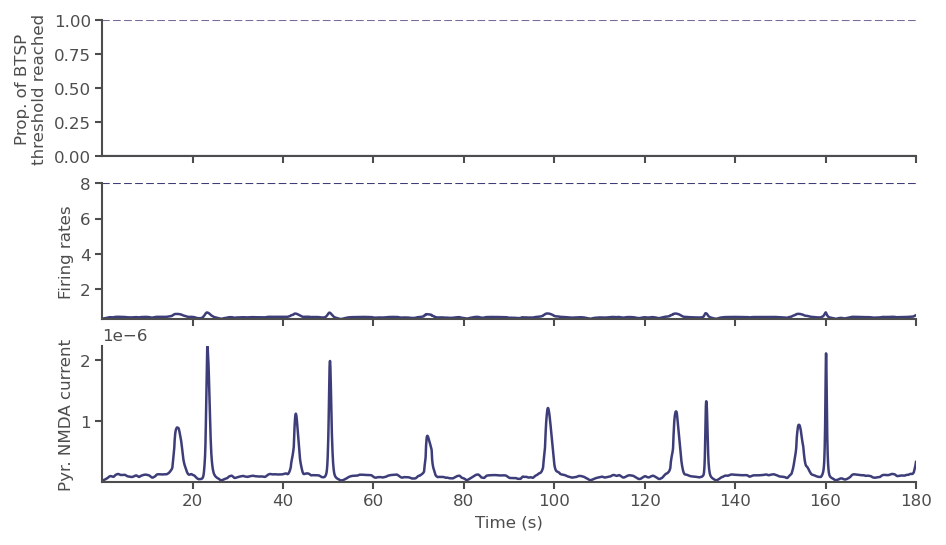

In [28]:
Pyrs.SomaCompartment.plot_BTSP_ramp();

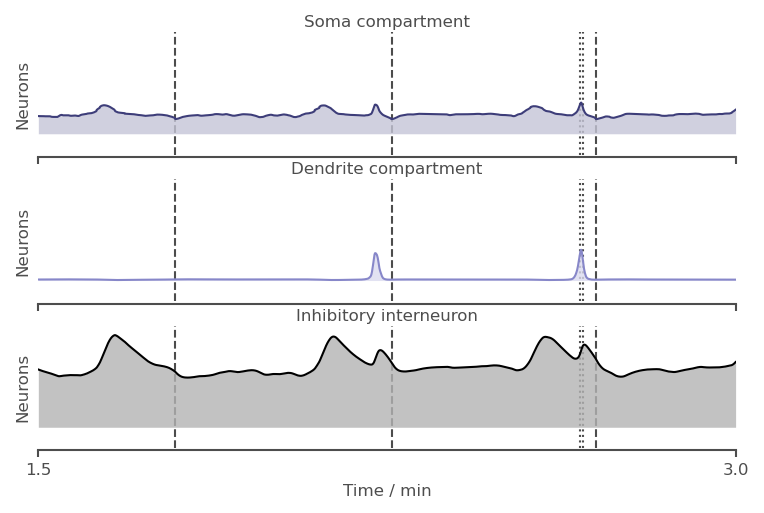

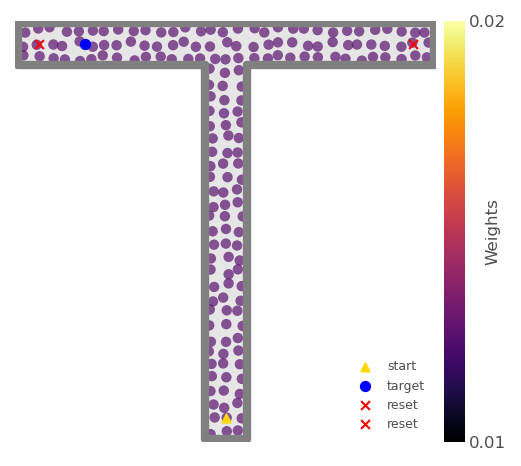

In [29]:
ax_time = Pyrs.plot_rate_timeseries(separate_axes=True, t_start=90, norm_by="shared_max")

fig_weights, ax_weights = plt.subplots(figsize=[3, 3])
plot_fcts.plot_2D_input_place_cell_weights(Pyrs.SomaCompartment, ax=ax_weights, s=25, plot_BTSP_events=True);